<a href="https://colab.research.google.com/github/theo-mattsa/telco-churn/blob/main/telco_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Download the dataset
import kagglehub
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print(path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
/kaggle/input/telco-customer-churn


In [ ]:
import pandas as pd
import seaborn as sns

## Quick look at the Data Structure

In [ ]:
telco = pd.read_csv(f'{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [ ]:
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
telco.isna().sum().sum()

np.int64(0)

In [ ]:
# Remove CustomerID
telco.drop(columns=['customerID'], inplace=True)

In [ ]:
print(f'Amount of duplicated rows: {telco.duplicated().sum()}')

# Remove duplicated rows
telco.drop_duplicates(inplace=True)

Amount of duplicated rows: 22


In [ ]:
telco['Churn'].value_counts()

,count
Churn,
No,5164
Yes,1857


In [ ]:
telco['DeviceProtection'].value_counts()

,count
DeviceProtection,
No,3087
Yes,2422
No internet service,1512


## Creating a test set

In [ ]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    telco, test_size=0.2, random_state=42, stratify=telco['Churn']
)

## Exploratory Data Analysis

## Univariate

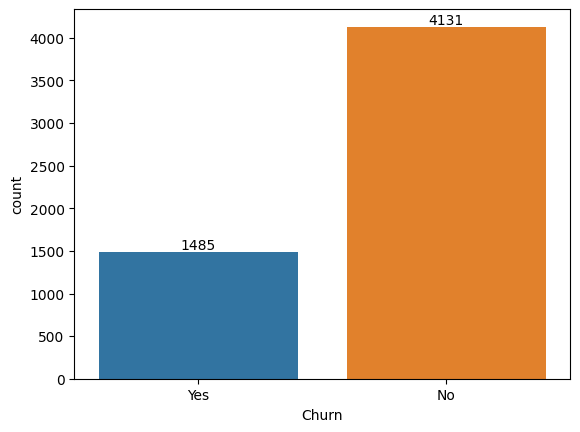

In [ ]:
ax = sns.countplot(data=train_set, x='Churn', hue='Churn')
for container in ax.containers:
  ax.bar_label(container)

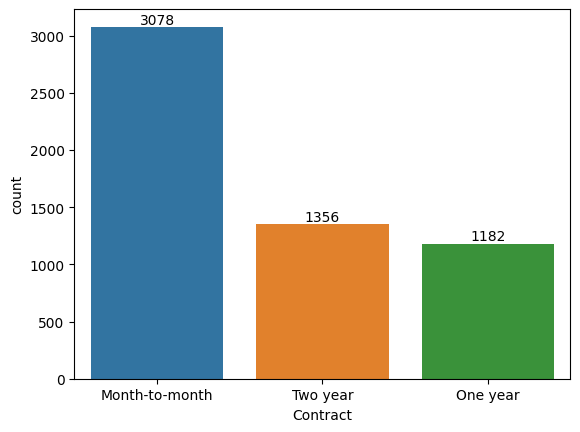

In [ ]:
ax = sns.countplot(data=train_set, x='Contract', hue='Contract')
for container in ax.containers:
  ax.bar_label(container)


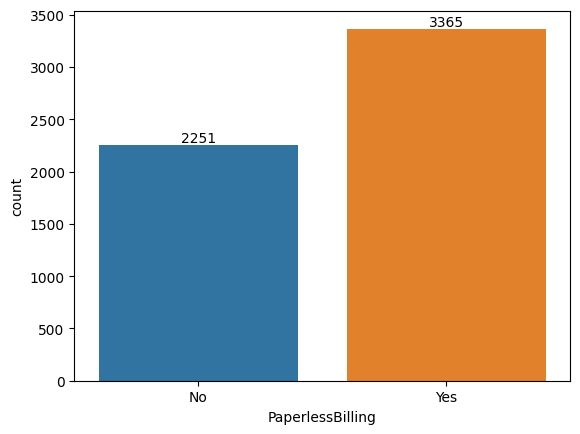

In [ ]:
ax = sns.countplot(data=train_set, x='PaperlessBilling', hue='PaperlessBilling')
for container in ax.containers:
  ax.bar_label(container)